In [6]:
import os
# Fix working directory if in notebooks
# Change to project root
if Path.cwd().name == "tft":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

## Cell 1: pick the latest run folder safely

In [7]:
from pathlib import Path
import pandas as pd

RUNS_ROOT = Path.home() / "pv_forecast_30d" / "experiments" / "tft" / "runs" / "germany" / "v1_0"

run_dirs = sorted([p for p in RUNS_ROOT.glob("*") if p.is_dir()])
assert run_dirs, f"No run dirs found under {RUNS_ROOT}"

# pick latest by folder name (your folders are timestamp-like)
latest = run_dirs[-1]

# if you want to be stricter: only pick runs that have metrics + checkpoints
def is_valid_run(p: Path) -> bool:
    has_metrics = (p / "logs" / "metrics.csv").exists() or (p / "metrics.csv").exists()
    has_ckpt = bool(list(p.rglob("*.ckpt")))
    return has_metrics and has_ckpt

valid = [p for p in run_dirs if is_valid_run(p)]
run_dir = valid[-1] if valid else latest

run_dir


PosixPath('/home/dwijenayake/pv_forecast_30d/experiments/tft/runs/germany/v1_0/20251222_171345')

## Read and plot metrics

In [15]:
import os
import matplotlib.pyplot as plt

metrics_path_candidates = [
    run_dir / "logs" / "version_0" / "metrics.csv",
    run_dir / "metrics.csv",
]
metrics_path = next((p for p in metrics_path_candidates if p.exists()), None)
assert metrics_path is not None, f"metrics.csv not found in {run_dir}"

dfm = pd.read_csv(metrics_path)
dfm.columns = [c.strip() for c in dfm.columns]
dfm.head(), dfm.tail(), dfm.columns


(   epoch  lr-AdamW  step  train_loss_epoch  train_loss_step  val_MAE  \
 0    NaN     0.001    49               NaN              NaN      NaN   
 1    0.0       NaN    49               NaN         0.049476      NaN   
 2    NaN     0.001    99               NaN              NaN      NaN   
 3    0.0       NaN    99               NaN         0.038078      NaN   
 4    NaN     0.001   149               NaN              NaN      NaN   
 
    val_MAPE  val_RMSE  val_SMAPE  val_loss  
 0       NaN       NaN        NaN       NaN  
 1       NaN       NaN        NaN       NaN  
 2       NaN       NaN        NaN       NaN  
 3       NaN       NaN        NaN       NaN  
 4       NaN       NaN        NaN       NaN  ,
      epoch  lr-AdamW  step  train_loss_epoch  train_loss_step   val_MAE  \
 127    7.0       NaN  2849               NaN         0.020145       NaN   
 128    NaN     0.001  2899               NaN              NaN       NaN   
 129    7.0       NaN  2899               NaN         0

loss cols: ['train_loss_epoch', 'train_loss_step', 'val_loss']


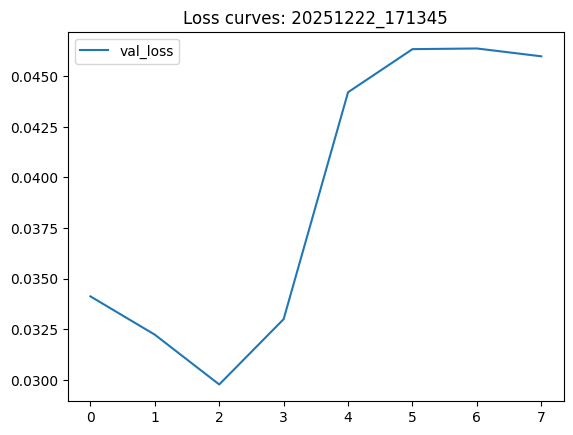

In [16]:
# common columns: epoch, step, train_loss, val_loss, etc
loss_cols = [c for c in dfm.columns if "loss" in c.lower()]
print("loss cols:", loss_cols)

# plot whatever looks like training vs validation
plt.figure()
for c in loss_cols:
    if c.lower() in {"train_loss", "val_loss", "loss"} or "val" in c.lower():
        plt.plot(dfm[c].dropna().values, label=c)
plt.legend()
plt.title(f"Loss curves: {run_dir.name}")
plt.show()


## locate the best checkpoint

In [17]:
import re

ckpts = sorted(run_dir.rglob("*.ckpt"))
assert ckpts, f"No .ckpt files found under {run_dir}"

# Heuristic: prefer "best" in filename, else latest modified
best = [p for p in ckpts if "best" in p.name.lower()]
ckpt_path = best[0] if best else max(ckpts, key=lambda p: p.stat().st_mtime)

ckpt_path


PosixPath('/home/dwijenayake/pv_forecast_30d/experiments/tft/runs/germany/v1_0/20251222_171345/best.ckpt')

## Rebuild dataset exactly like training and load model

This assumes:

- your final parquets are here
'data/processed/pretraining/germany/global/tft_inputs/regional_train_tft_full.parquet'

- 'data/processed/pretraining/germany/global/tft_inputs/regional_val_tft_full.parquet'

- your config is in 'src/configs/tft_v1.py'

In [ ]:
import sys
import numpy as np
import torch

REPO_ROOT = Path.home() / "pv_forecast_30d"
sys.path.insert(0, str(REPO_ROOT))

train_p = REPO_ROOT / "data/processed/pretraining/germany/global/tft_inputs/regional_train_tft_full.parquet"
val_p   = REPO_ROOT / "data/processed/pretraining/germany/global/tft_inputs/regional_val_tft_full.parquet"
assert train_p.exists() and val_p.exists()

train = pd.read_parquet(train_p)
val   = pd.read_parquet(val_p)

# Make sure timestamps are tz-aware UTC
train["timestamp_utc"] = pd.to_datetime(train["timestamp_utc"], utc=True)
val["timestamp_utc"]   = pd.to_datetime(val["timestamp_utc"], utc=True)

# Import your config (edit names if yours differ)
from src.configs.tft_v1 import TFTConfig  
cfg = TFTConfig()
cfg


ImportError: cannot import name 'TFTConfig' from 'src.configs.tft_v1' (/home/dwijenayake/pv_forecast_30d/src/configs/tft_v1.py)

Now create time_idx consistently (15 min steps). If your training script already created it, reuse that column. If not, do this:

In [ ]:
# If time_idx already exists, skip.
if "time_idx" not in train.columns:
    # global time index over all plants, based on sorted unique timestamps
    all_ts = pd.Index(pd.concat([train["timestamp_utc"], val["timestamp_utc"]]).unique()).sort_values()
    ts_to_idx = {ts: i for i, ts in enumerate(all_ts)}
    train["time_idx"] = train["timestamp_utc"].map(ts_to_idx).astype("int64")
    val["time_idx"]   = val["timestamp_utc"].map(ts_to_idx).astype("int64")

train[["timestamp_utc","time_idx"]].head(), val[["timestamp_utc","time_idx"]].head()


Build TimeSeriesDataSet:

In [ ]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

TARGET = "power_norm"
GROUP  = ["plant_id"]
TIME   = "time_idx"

# IMPORTANT: drop the GTI proxy if you decided to remove it
DROP_COLS = ["poa_irradiance"]  # if present
for c in DROP_COLS:
    if c in train.columns:
        train = train.drop(columns=[c])
    if c in val.columns:
        val = val.drop(columns=[c])

# You must align these lists to your cfg file.
# Example convention (edit to match your cfg object):
static_categoricals = ["plant_id"]
time_varying_known_reals = cfg.known_reals
time_varying_unknown_reals = cfg.unknown_reals
time_varying_known_categoricals = cfg.known_categoricals if hasattr(cfg, "known_categoricals") else []

max_encoder_length = cfg.max_encoder_length
max_prediction_length = cfg.max_prediction_length

train_ds = TimeSeriesDataSet(
    train,
    time_idx=TIME,
    target=TARGET,
    group_ids=GROUP,
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_categoricals=time_varying_known_categoricals,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=None,                # because power_norm already 0..1
    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
    allow_missing_timesteps=True,          # you already saw why this matters
)

val_ds = TimeSeriesDataSet.from_dataset(train_ds, val, predict=True, stop_randomization=True)

train_dl = train_ds.to_dataloader(train=True, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
val_dl   = val_ds.to_dataloader(train=False, batch_size=cfg.batch_size, num_workers=cfg.num_workers)

len(train_dl), len(val_dl)


Load model:

In [ ]:
from pytorch_forecasting.models import TemporalFusionTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
tft = TemporalFusionTransformer.load_from_checkpoint(str(ckpt_path))
tft.to(device)
tft.eval()

tft.hparams


## predict on val, compute per-horizon and per-plant metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# predictions: (n, pred_len)
pred = tft.predict(val_dl, mode="prediction", return_index=True, return_y=True)

# Depending on version, this may return a tuple-like object.
# Handle common shapes robustly:
if isinstance(pred, tuple) and len(pred) == 3:
    y_hat, index, y_true = pred
else:
    # fallback
    y_hat = pred.output if hasattr(pred, "output") else pred[0]
    index = pred.index if hasattr(pred, "index") else pred[1]
    y_true = pred.y if hasattr(pred, "y") else pred[2]

y_hat = np.asarray(y_hat)
y_true = np.asarray(y_true)

print("y_hat:", y_hat.shape, "y_true:", y_true.shape)
index.head()


In [ ]:
# Flatten per horizon metrics
H = y_hat.shape[1]
rows = []
for h in range(H):
    rmse = mean_squared_error(y_true[:, h], y_hat[:, h], squared=False)
    mae  = mean_absolute_error(y_true[:, h], y_hat[:, h])
    rows.append({"horizon_step": h+1, "rmse": rmse, "mae": mae})

pd.DataFrame(rows).head(10)


In [ ]:
# Per-plant aggregated over all horizons (simple)
idx = index.copy()
idx["y_true_mean"] = y_true.mean(axis=1)
idx["y_hat_mean"]  = y_hat.mean(axis=1)

out = []
for pid, g in idx.groupby("plant_id"):
    rmse = mean_squared_error(g["y_true_mean"], g["y_hat_mean"], squared=False)
    mae  = mean_absolute_error(g["y_true_mean"], g["y_hat_mean"])
    out.append({"plant_id": pid, "rmse": rmse, "mae": mae, "n": len(g)})

pd.DataFrame(out).sort_values("rmse")


### export a report next to the run directory

In [ ]:
report_dir = run_dir / "sanity"
report_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(rows).to_csv(report_dir / "val_metrics_by_horizon.csv", index=False)
pd.DataFrame(out).to_csv(report_dir / "val_metrics_by_plant.csv", index=False)

with open(report_dir / "ckpt_used.txt", "w") as f:
    f.write(str(ckpt_path) + "\n")

print("Wrote:", report_dir)
